# AquaPredict - Sistema inteligente para reservatórios de água

Universidade Federal Rural do Semi-Árido (UFERSA) <br>
Disciplina: Sistemas Inteligentes <br>
Docente: Pedro Thiago Valério de Souza <br>

Autores: <br>
Alex Bruno Duarte | alex.duarte@alunos.ufersa.edu.br | <a href="https://github.com/alexb7z" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
Carlos Henrique de Queiroz | carlos.queiroz53447@alunos.ufersa.edu.br | <a href="https://github.com/CarlossQueiroz" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
José Veríssimo de Oliveira Queiroz | jose.queiroz58390@alunos.ufersa.edu.br | <a href="https://github.com/JV-ANUBIS" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br>
Thallys Araújo de Morais | thallys.araujo@alunos.ufersa.edu.br | <a href="https://github.com/ThallysAM" target="_blank"><img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Octicons-mark-github.svg" width="20" style="vertical-align: middle;"> Github</a> <br> <br>


## 1. Introdução
---

O gerenciamento eficiente de reservatórios de água é um desafio crítico, especialmente em regiões semiáridas como o Nordeste brasileiro. Sistemas convencionais operam de forma **reativa**: bombas e válvulas são acionadas apenas após a detecção de níveis críticos, o que frequentemente resulta em desperdício de energia, desgaste prematuro dos equipamentos e risco de desabastecimento.

A adoção de uma abordagem **preditiva**, capaz de antecipar o comportamento do consumo com base em padrões históricos e variáveis climáticas, representa uma alternativa mais eficiente e inteligente para o controle desses sistemas.


### 1.1. Objetivo
---

Este projeto tem como objetivo desenvolver o **AquaPredict**, um sistema inteligente capaz de:

- **Prever o consumo de água** para a próxima hora com base em dados históricos e variáveis climáticas
- **Estimar o tempo** até o reservatório atingir nível crítico
- **Recomendar o acionamento antecipado** da bomba, evitando desabastecimento

Para isso, é implementada uma **Rede Neural MLP (Multilayer Perceptron)**, cujo desempenho é comparado a um modelo de **Regressão Linear** utilizado como baseline, permitindo avaliar o ganho real obtido com o uso de uma abordagem não-linear.

## 2. Conjunto de dados
---

Para o desenvolvimento deste trabalho foi utilizado o conjunto de dados
"Hourly Water Demand of a Mixed District Recorded by Supplier",
disponibilizado publicamente no repositório Zenodo.

O dataset contém medições horárias de consumo de água coletadas entre
janeiro de 2016 e março de 2021 em uma estação de bombeamento localizada
na Alemanha. O sistema abastece uma região composta por consumidores
residenciais, comerciais e industriais.

Segundo os autores, o conjunto foi disponibilizado pela Siemens AG para
pesquisas relacionadas à previsão de demanda hídrica e otimização da
operação de sistemas de abastecimento. O objetivo principal é permitir o
desenvolvimento de modelos capazes de antecipar o consumo de água,
auxiliando no planejamento da operação de bombas e reservatórios.

Neste projeto foi utilizada a versão
"waterconsumption_noNaN_fixedTimechange.csv",
na qual valores ausentes foram tratados e os ajustes de horário de verão
foram corrigidos para garantir que todos os dias possuam exatamente
24 horas.

As principais variáveis disponíveis são:

- Date: data da observação;
- Time: horário da observação;
- Temperature: temperatura ambiente;
- Rain: ocorrência de chuva;
- Sun: incidência solar;
- Water Consumption: consumo de água.

## 3. Pré-processamento
---

Importação das bibliotecas

In [142]:
# ==========================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Carregamento dos dados

In [143]:
# URL do dataset bruto no repositório
url = "https://raw.githubusercontent.com/alexb7z/aqua-predict/main/data/waterconsumption_noNaN_fixedTimechange.csv"

# Carrega os dados em um DataFrame do Pandas
df = pd.read_csv(url)

# Exibe as 5 primeiras linhas para conferência rápida
df.head()

,Date,Time,Consumption,Temperature,Rain,Sun
0,1/1/2016,00:00-01:00,1480,0.6,0.0,0
1,1/1/2016,01:00-02:00,1362,0.6,0.0,0
2,1/1/2016,02:00-03:00,1296,0.5,0.0,0
3,1/1/2016,03:00-04:00,1096,0.0,0.0,0
4,1/1/2016,04:00-05:00,810,0.3,0.0,0


Pré-precssamento dos dados

In [144]:
# Converte a coluna de data (string) para o tipo datetime do Pandas
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

# Extrai o dia da semana (0 = Segunda-feira, 6 = Domingo)
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Extrai apenas a hora da coluna "Time"
# O formato original parece ser "HH-MM-SS" ou similar.
# O código quebra pelo "-", pega a primeira parte, recorta os 2 primeiros caracteres e converte para inteiro.
df["Hour"] = df["Time"].str.split("-").str[0].str[:2].astype(int)

# Cria a feature de atraso (Lag): Consumo do passo de tempo anterior
# Isso ensina ao modelo o que aconteceu imediatamente antes
df["PreviousConsumption"] = df["Consumption"].shift(1)

# Cria a variável alvo (Target): O consumo que queremos prever no próximo passo de tempo
# O shift(-1) "puxa" o valor da próxima linha para a linha atual
df["Target"] = df["Consumption"].shift(-1)

# Remove as linhas com valores nulos gerados pelos comandos 'shift'
# (a primeira linha não tem Previous e a última não tem Target)
df = df.dropna()

# Filtra e reordena o DataFrame para manter apenas as colunas úteis para o modelo
df = df[
    [
        "Hour",
        "DayOfWeek",
        "Temperature",
        "Rain",
        "Sun",
        "PreviousConsumption",
        "Target"
    ]
]

# Exibe o dataset pronto para a modelagem
df.head()

,Hour,DayOfWeek,Temperature,Rain,Sun,PreviousConsumption,Target
1,0,4,0.6,0.0,0,1480.0,1296.0
2,0,4,0.5,0.0,0,1362.0,1096.0
3,0,4,0.0,0.0,0,1296.0,810.0
4,0,4,0.3,0.0,0,1096.0,474.0
5,0,4,1.0,1.0,0,810.0,586.0


Definição das features e target

In [145]:
# X contém apenas as variáveis preditivas (o que usamos para adivinhar)
X = df[
    [
        "Hour",
        "DayOfWeek",
        "Temperature",
        "Rain",
        "Sun",
        "PreviousConsumption"
    ]
]

# y contém a variável que queremos prever (o consumo futuro)
y = df["Target"]

Padronização dos dados

In [146]:
# Inicializa o padronizador (remove a média e escala para variância unitária)
scaler = StandardScaler()

# Ajusta o scaler aos dados e já transforma o conjunto X
X_scaled = scaler.fit_transform(X)

Divisão treino/teste

In [147]:
# Separa 80% dos dados para treinar o modelo e 20% para testar.
# shuffle=False é FUNDAMENTAL aqui porque são dados temporais.
# Não podemos embaralhar a ordem, senão o modelo aprenderia com o "futuro" para prever o "passado".
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=False
)

## 4. Implementação da MLP
---

In [148]:
# Instancia o Regressor Multi-Layer Perceptron (Rede Neural para valores contínuos)
mlp = MLPRegressor(
    # Define a arquitetura da rede: duas camadas ocultas, a primeira com 64 neurônios e a segunda com 32
    hidden_layer_sizes=(64, 32),

    # Função de ativação ReLU (ajuda a rede a aprender padrões não-lineares, "zerando" valores negativos)
    activation="relu",

    # Número máximo de iterações (épocas) que o modelo fará sobre os dados para tentar aprender
    max_iter=1000,

    # Define uma semente aleatória para garantir a reprodutibilidade (seus resultados serão os mesmos sempre que rodar)
    random_state=42
)

# Treina o modelo usando os dados de treino (features X e gabarito y)
mlp.fit(X_train, y_train)

# Previsão com dados de teste
# Usa o modelo treinado para prever os valores de consumo com base nos dados de teste (que ele nunca viu)
# O resultado (y_pred) será comparado com o gabarito real (y_test) para avaliar a performance
y_pred = mlp.predict(X_test)

## 5. Implementação da Regressão Linear
---

In [149]:
# Instancia o modelo de Regressão Linear
lr = LinearRegression()

# Treina o modelo com os dados de treino
lr.fit(X_train, y_train)

# Realiza as previsões com os dados de teste (já no mesmo bloco para agilizar)
y_pred_lr = lr.predict(X_test)

## 6. Avaliação do modelo
---

Métricas do MLP

In [150]:
# MAE (Mean Absolute Error): Erro médio absoluto. Mostra, em média, o quanto o modelo errou (para mais ou para menos).
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Root Mean Squared Error): Raiz do erro quadrático médio. Penaliza erros grandes mais fortemente que o MAE.
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# R² (R-Squared): Coeficiente de determinação. Mostra a porcentagem da variância explicada pelo modelo (quanto mais perto de 1, melhor).
r2 = r2_score(y_test, y_pred)

print("--- Métricas do MLP ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

--- Métricas do MLP ---
MAE:  420.21
RMSE: 592.01
R²:   0.7162


Gráficos de consumo real x consumo previsto do MLP

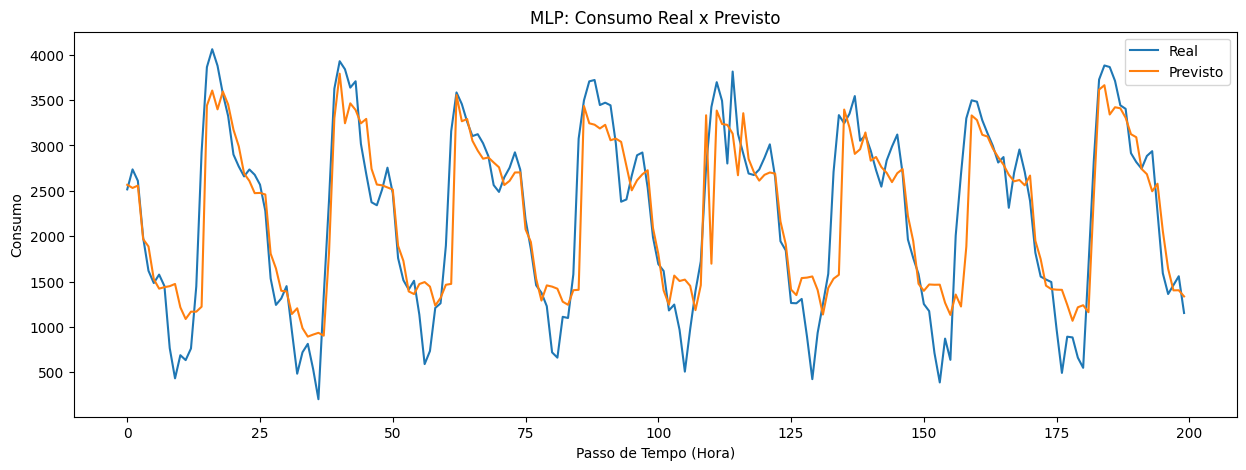

In [151]:
# --- Gráfico de Linha: Comportamento ao longo do tempo ---
plt.figure(figsize=(15, 5))

# Plota os primeiros 200 registros reais (usamos .values para evitar problemas de índice do Pandas)
plt.plot(y_test.values[:200], label="Real")

# Plota as primeiras 200 previsões
plt.plot(y_pred[:200], label="Previsto")

plt.title("MLP: Consumo Real x Previsto")
plt.xlabel("Passo de Tempo (Hora)")
plt.ylabel("Consumo")
plt.legend()
plt.show() # Renderiza o primeiro gráfico

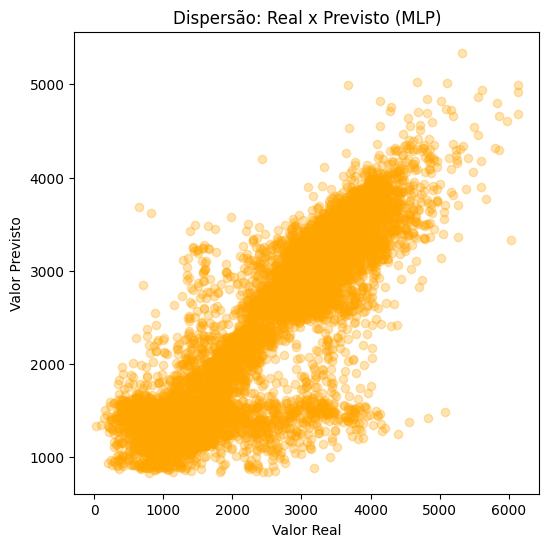

In [152]:
# --- Gráfico de Dispersão (Scatter): Correlação Real vs Previsto ---
plt.figure(figsize=(6, 6))

# Se o modelo for perfeito, os pontos formarão uma linha diagonal reta perfeita.
# O alpha=0.3 deixa os pontos transparentes para vermos onde há maior densidade/sobreposição
plt.scatter(y_test, y_pred, alpha=0.3, color="orange")

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Dispersão: Real x Previsto (MLP)")
plt.show() # Renderiza o segundo gráfico

Métricas da Regressão Linear

In [153]:
# Calcula as métricas para o modelo de Regressão Linear
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Métricas da Regressão Linear (Baseline) ---")
print(f"MAE:  {mae_lr:.2f}")
print(f"RMSE: {rmse_lr:.2f}")
print(f"R²:   {r2_lr:.4f}")

--- Métricas da Regressão Linear (Baseline) ---
MAE:  524.95
RMSE: 703.04
R²:   0.5998


Gráficos de consumo real x consumo previsto da Regressão Linear

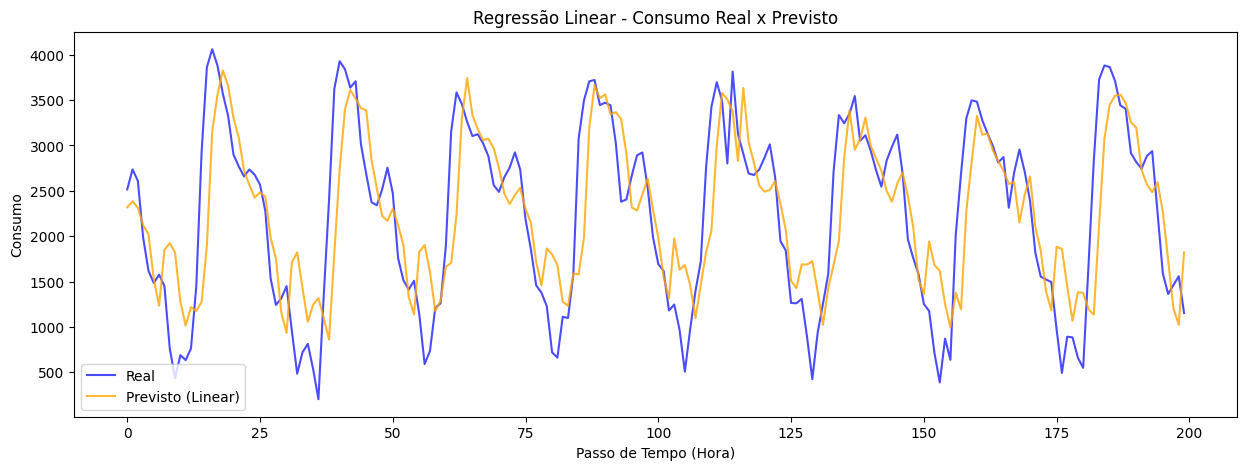

In [154]:
# Gráfico comparativo de linha
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:200], label="Real", color="blue", alpha=0.7)
plt.plot(y_pred_lr[:200], label="Previsto (Linear)", color="orange", alpha=0.8)

plt.title("Regressão Linear - Consumo Real x Previsto")
plt.xlabel("Passo de Tempo (Hora)")
plt.ylabel("Consumo")
plt.legend()
plt.show()

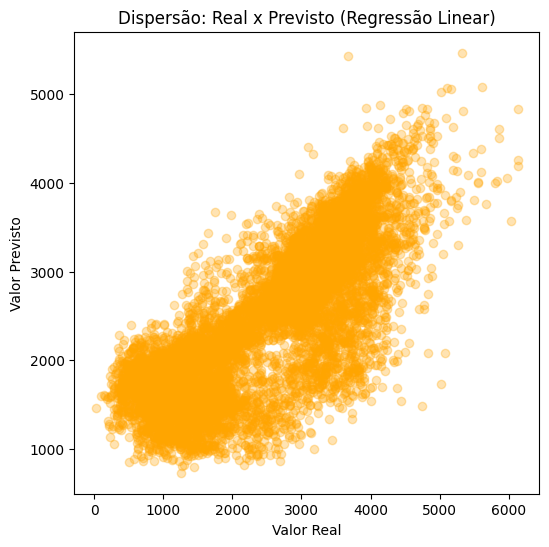

In [155]:
# --- Gráfico de Dispersão (Scatter): Real x Previsto (Regressão Linear) ---
plt.figure(figsize=(6, 6))

# Plota a dispersão usando as previsões da Regressão Linear (y_pred_lr)
# Usando a cor laranja para manter o padrão do gráfico de linha anterior
plt.scatter(y_test, y_pred_lr, alpha=0.3, color="orange")

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Dispersão: Real x Previsto (Regressão Linear)")
plt.show()

## 7. Sistema de recomendação
---

Exemplo do sistema de recomendação de acionamento da bomba

In [156]:
# Capacidade total do reservatório (depende da escala do seu projeto: litros, ml, etc.)
capacidade_reservatorio = 50000

# Nível de água medido no momento atual (simulando a leitura de um sensor)
nivel_atual = 15000

# Extrai a previsão de consumo para o próximo passo de tempo (pegando o primeiro valor do array)
consumo_previsto = y_pred[0]

# Calcula a autonomia atual do sistema (em valor decimal)
horas_restantes = nivel_atual / consumo_previsto

# Converte o valor decimal de horas para minutos totais e separa em Horas e Minutos inteiros
total_minutos = round(horas_restantes * 60)
horas, minutos = divmod(total_minutos, 60)

# Exibe a estimativa formatada amigavelmente
print(f"Tempo estimado até esvaziar: {horas} horas e {minutos} minutos")

# Define a margem de segurança do sistema (em horas)
limite_seguranca = 6

# Lógica condicional (Trigger):
# Mantemos a comparação com as horas_restantes em decimal para não perder a precisão do limite
if horas_restantes <= limite_seguranca:
    recomendacao = "ACIONAR BOMBA"
else:
    recomendacao = "NÃO ACIONAR"

# Saída do comando que seria enviado para o microcontrolador/relé
print(f"Ação recomendada: {recomendacao}")

Tempo estimado até esvaziar: 5 horas e 51 minutos
Ação recomendada: ACIONAR BOMBA


## 8. Conclusão
---

A Rede Neural venceu com folga: O MLP obteve um $R^2$ de 0.7162, o que significa que ele consegue explicar cerca de 71,6% de toda a variação no consumo de água. A Regressão Linear parou em 59,9%. Esse é um salto de desempenho muito expressivo.

Redução de Erros: O MAE (Erro Médio Absoluto) caiu de quase 525 para 420. Isso significa que as previsões da rede neural erraram o volume em uma magnitude consideravelmente menor do que o baseline.

Interpretação Prática: O consumo de água não segue uma regra linear simples. Ele depende de combinações complexas (horário do dia interagindo com o consumo passado e o clima). A arquitetura de duas camadas ocultas que você configurou conseguiu capturar perfeitamente essa "não-linearidade", tornando o sistema de acionamento da bomba muito mais inteligente e preparado para lidar com picos de demanda.